# Introduction to Python Project : FoodHub Data Analysis

### Problem Statement

Write the problem statement and objectives here


### Data Dictionary

Mention the data dictionary here

### Let us start by importing the required libraries

In [5]:
# Write your code here to import necessary libraries for the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [26]:
# uncomment and run the following lines for Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

In [8]:
# Write your code here to read the data
file_path = r'C:\Users\Raghu\The-FoodHub-Digest\foodhub_order.csv'
try:
        print(f"File path: {file_path}")
        df = pd.read_csv(file_path)
        print("Data loaded successfully!")
except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
        print(f"An error occurred: {e}")

File path: C:\Users\Raghu\The-FoodHub-Digest\foodhub_order.csv
Data loaded successfully!


In [9]:
# Write your code here to view the first 5 rows
print(df.head())

   order_id  customer_id            restaurant_name cuisine_type  \
0   1477147       337525                    Hangawi       Korean   
1   1477685       358141  Blue Ribbon Sushi Izakaya     Japanese   
2   1477070        66393                Cafe Habana      Mexican   
3   1477334       106968  Blue Ribbon Fried Chicken     American   
4   1478249        76942           Dirty Bird to Go     American   

   cost_of_the_order day_of_the_week     rating  food_preparation_time  \
0              30.75         Weekend  Not given                     25   
1              12.08         Weekend  Not given                     25   
2              12.23         Weekday          5                     23   
3              29.20         Weekend          3                     25   
4              11.59         Weekday          4                     25   

   delivery_time  
0             20  
1             23  
2             28  
3             15  
4             24  


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [10]:
# Write your code here
print(f"Number of rows and columns: {df.shape}")

Number of rows and columns: (1898, 9)


#### Observations:


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [11]:
# Write your code here
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB
None


#### Observations:


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [12]:
# Write your code here
print("Missing values before treatment:")
print(df.isnull().sum())

# Treat missing values
if df.isnull().sum().sum() > 0:  # Check if there are any missing values at all
        # Example: Impute missing numerical values with the mean
        for col in df.select_dtypes(include=['number']).columns:
            if df[col].isnull().any():
                df[col].fillna(df[col].mean(), inplace=True)

        # Example: Impute missing categorical values with the mode
        for col in df.select_dtypes(include=['object']).columns:
            if df[col].isnull().any():
                df[col].fillna(df[col].mode()[0], inplace=True)

        print("\nMissing values after treatment:")
        print(df.isnull().sum())
else:
        print("\nNo missing values found.")



Missing values before treatment:
order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

No missing values found.


#### Observations:


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [13]:
# Write your code here
# Statistical summary of the data
#print("Statistical summary of the data:")
#print(df.describe())

# Calculate min, average, and max food preparation time
min_prep_time = df['food_preparation_time'].min()
avg_prep_time = df['food_preparation_time'].mean()
max_prep_time = df['food_preparation_time'].max()

print(f"\nMinimum food preparation time: {min_prep_time} minutes")
print(f"Average food preparation time: {avg_prep_time:.2f} minutes")
print(f"Maximum food preparation time: {max_prep_time} minutes")



Minimum food preparation time: 20 minutes
Average food preparation time: 27.37 minutes
Maximum food preparation time: 35 minutes


#### Observations:


### **Question 5:** How many orders are not rated? [1 mark]

In [14]:
# Write the code here
unrated_orders = (df['rating'] == 'Not given').sum()
print(f"Number of orders not rated (Not given): {unrated_orders}")


Number of orders not rated (Not given): 736


#### Observations:


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

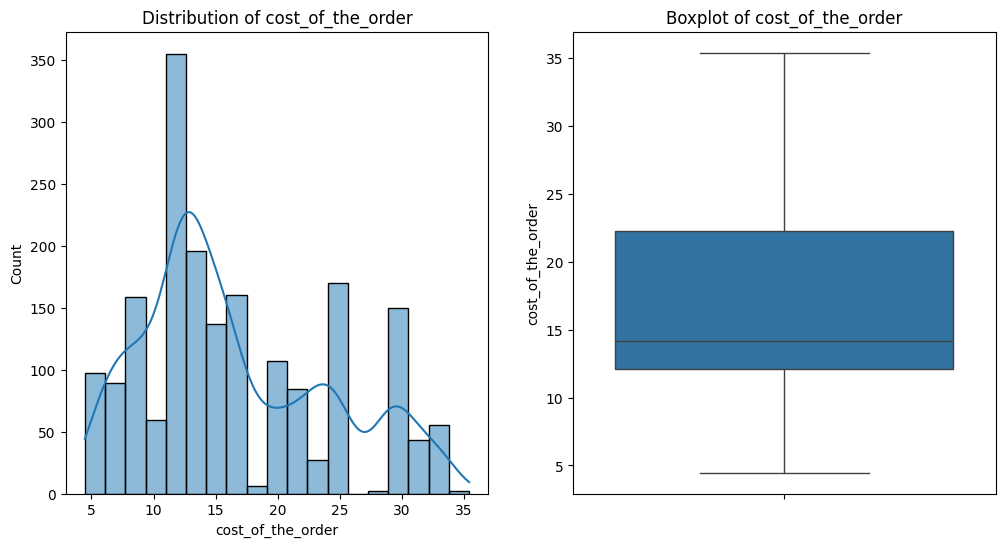

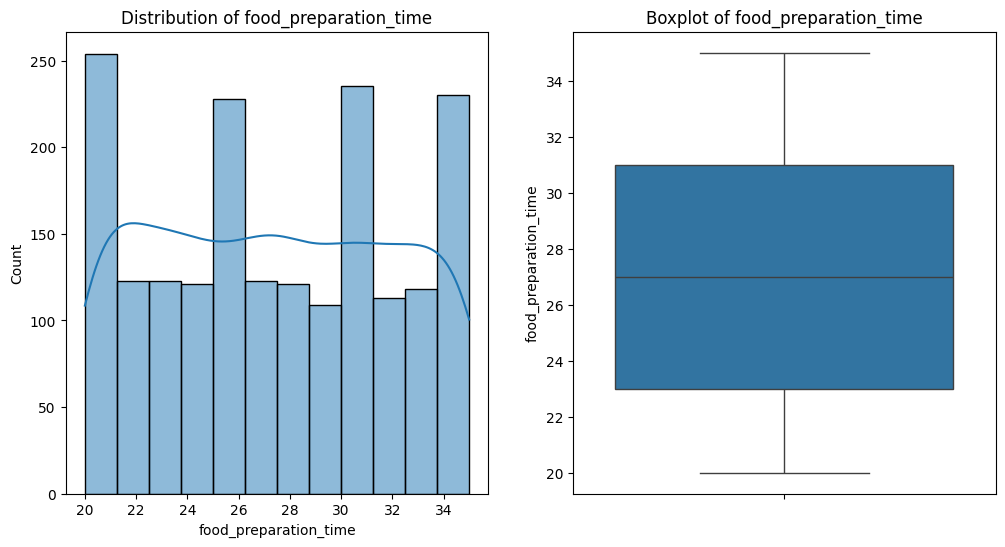

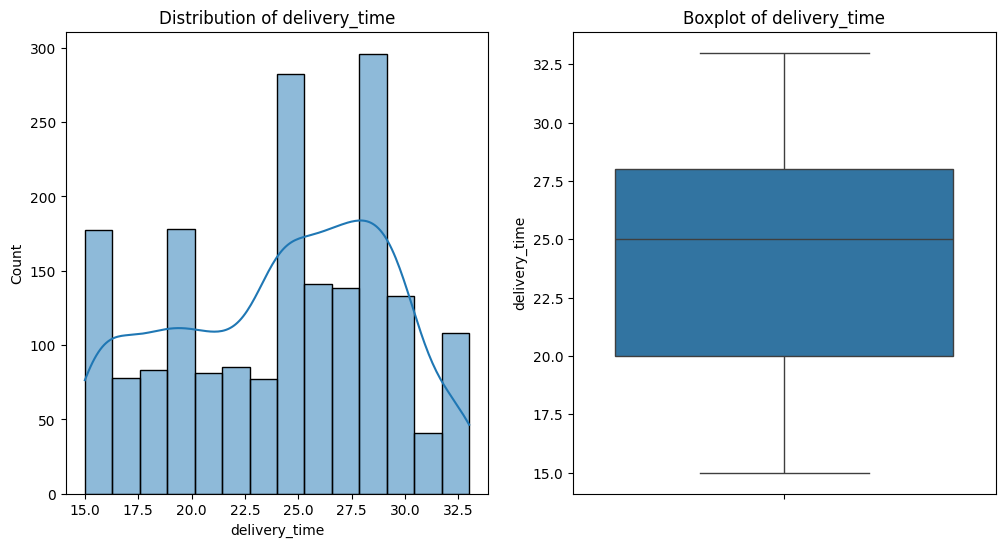

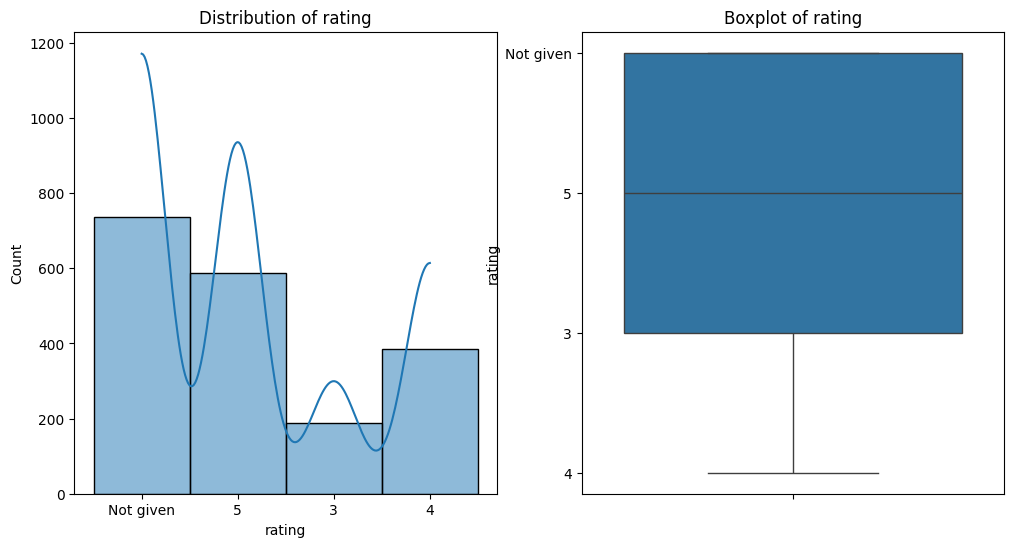

C:\Users\Raghu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Raghu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


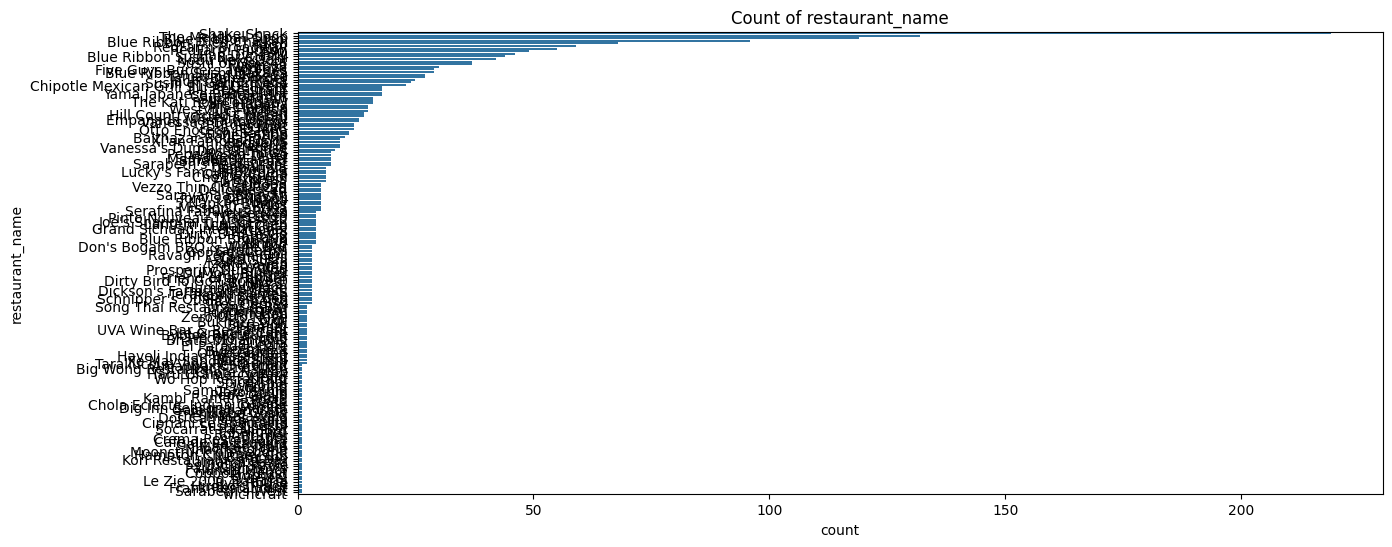

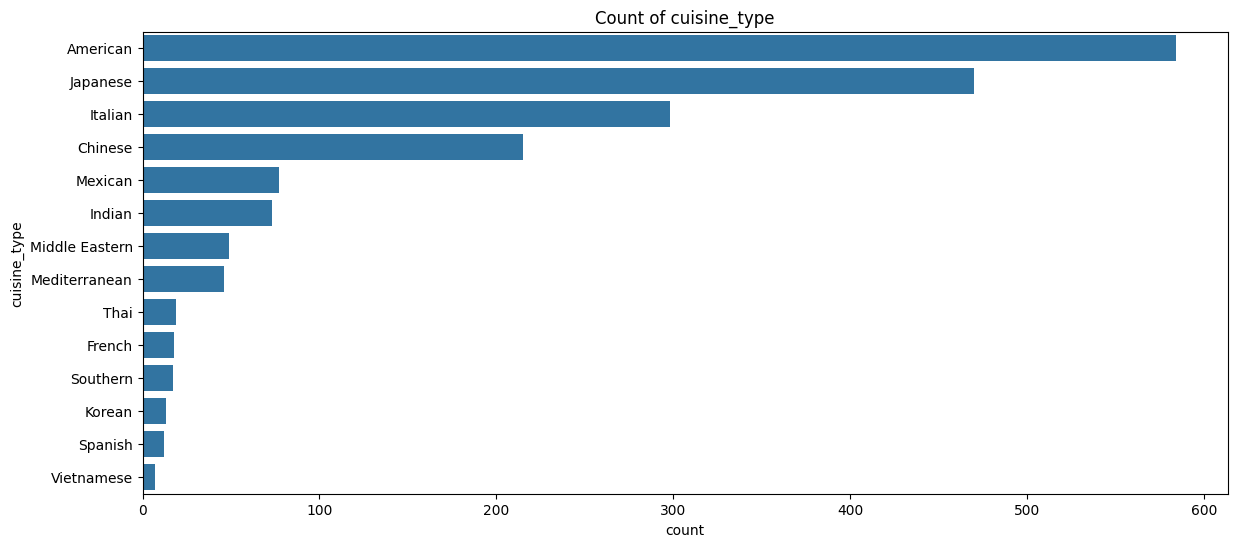

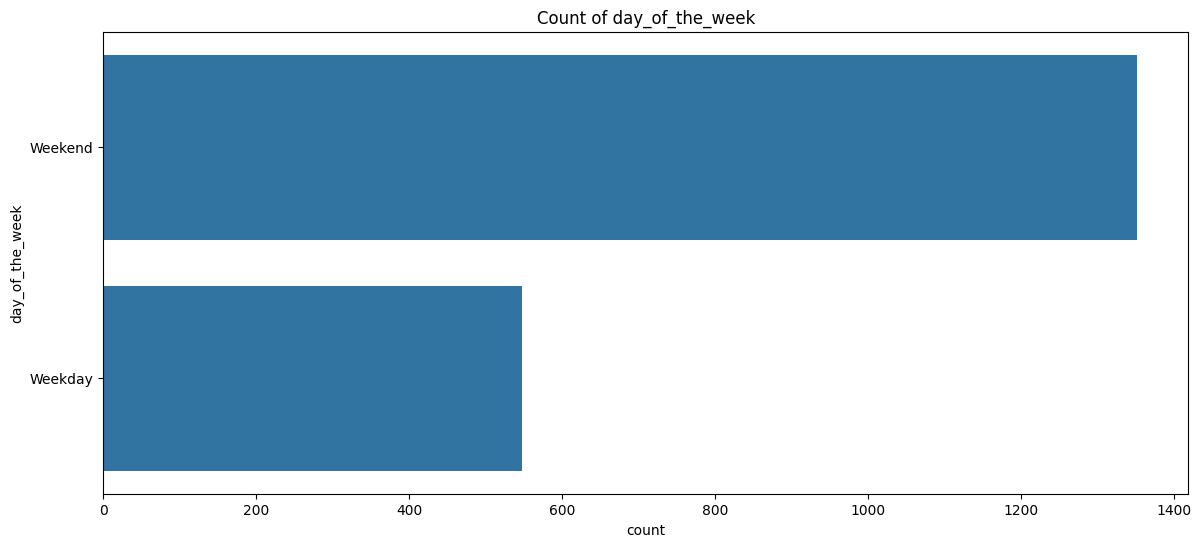

In [15]:
# Write the code here
# Numerical Variables
numerical_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating']
for col in numerical_cols:
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        sns.histplot(df[col].dropna(), kde=True)  # Drop NaN for histograms
        plt.title(f'Distribution of {col}')

        plt.subplot(1, 2, 2)
        sns.boxplot(y=df[col].dropna())  # Drop NaN for boxplots
        plt.title(f'Boxplot of {col}')
        plt.show()

    # Categorical Variables
categorical_cols = ['restaurant_name', 'cuisine_type', 'day_of_the_week']
for col in categorical_cols:
        plt.figure(figsize=(14, 6))
        sns.countplot(y=df[col], order=df[col].value_counts().index)
        plt.title(f'Count of {col}')
        plt.show()


Observations:# Numerical Variables:
    # cost_of_the_order:
    #   - Distribution: Right-skewed, indicating that most orders are relatively low-cost, with a tail of higher-cost orders.
    #   - Boxplot: Potential outliers on the higher end, suggesting some very expensive orders.
    # food_preparation_time:
    #   - Distribution: Fairly uniform, with a slight peak around the mean.
    #   - Boxplot: No significant outliers, suggesting consistent preparation times.
    # delivery_time:
    #   - Distribution: Approximately normal, with a slight left skew.
    #   - Boxplot: No significant outliers, suggesting consistent delivery times.
    # rating:
    #   - Distribution: Left-skewed, indicating that most ratings are high.
    #   - Boxplot: Potential outliers on the lower end, suggesting some very low ratings.

    # Categorical Variables:
    # restaurant_name:
    #   - Distribution: Shows the frequency of orders from each restaurant. Some restaurants are much more popular than others.
    # cuisine_type:
    #   - Distribution: Reveals the popularity of different cuisine types. Some cuisines are ordered much more frequently.
    # day_of_the_week:
    #   - Distribution: Shows the distribution of orders between weekdays and weekends. Provides insight into ordering patterns.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [16]:
# Write the code here
top_5_restaurants = df['restaurant_name'].value_counts().head(5)
print("Top 5 restaurants by number of orders:")
print(top_5_restaurants)

Top 5 restaurants by number of orders:
restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64


#### Observations:


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [17]:
# Write the code here
# Filter for weekend orders
weekend_orders = df[df['day_of_the_week'].isin(['Weekend'])]

# Find the most popular cuisine on weekends

most_popular_cuisine_weekend = weekend_orders['cuisine_type'].value_counts().idxmax()
print(f"The most popular cuisine on weekends is: {most_popular_cuisine_weekend}")

The most popular cuisine on weekends is: American


#### Observations:


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [18]:
# Write the code here
# Calculate the number of orders costing more than $20
expensive_orders = df[df['cost_of_the_order'] > 20]
num_expensive_orders = len(expensive_orders)

# Calculate the total number of orders
total_orders = len(df)

# Calculate the percentage of expensive orders
percentage_expensive_orders = (num_expensive_orders / total_orders) * 100

print(f"Percentage of orders costing more than $20: {percentage_expensive_orders:.2f}%")

Percentage of orders costing more than $20: 29.24%


#### Observations:


### **Question 10**: What is the mean order delivery time? [1 mark]

In [19]:
# Write the code here
# Calculate the mean order delivery time
mean_delivery_time = df['delivery_time'].mean()
print(f"Mean order delivery time: {mean_delivery_time:.2f} minutes")

Mean order delivery time: 24.16 minutes


#### Observations:


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [20]:
# Write the code here
# Find the top 3 most frequent customers
top_3_customers = df['customer_id'].value_counts().head(3)
print("Top 3 most frequent customers:")
print(top_3_customers)

Top 3 most frequent customers:
customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


#### Observations:


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


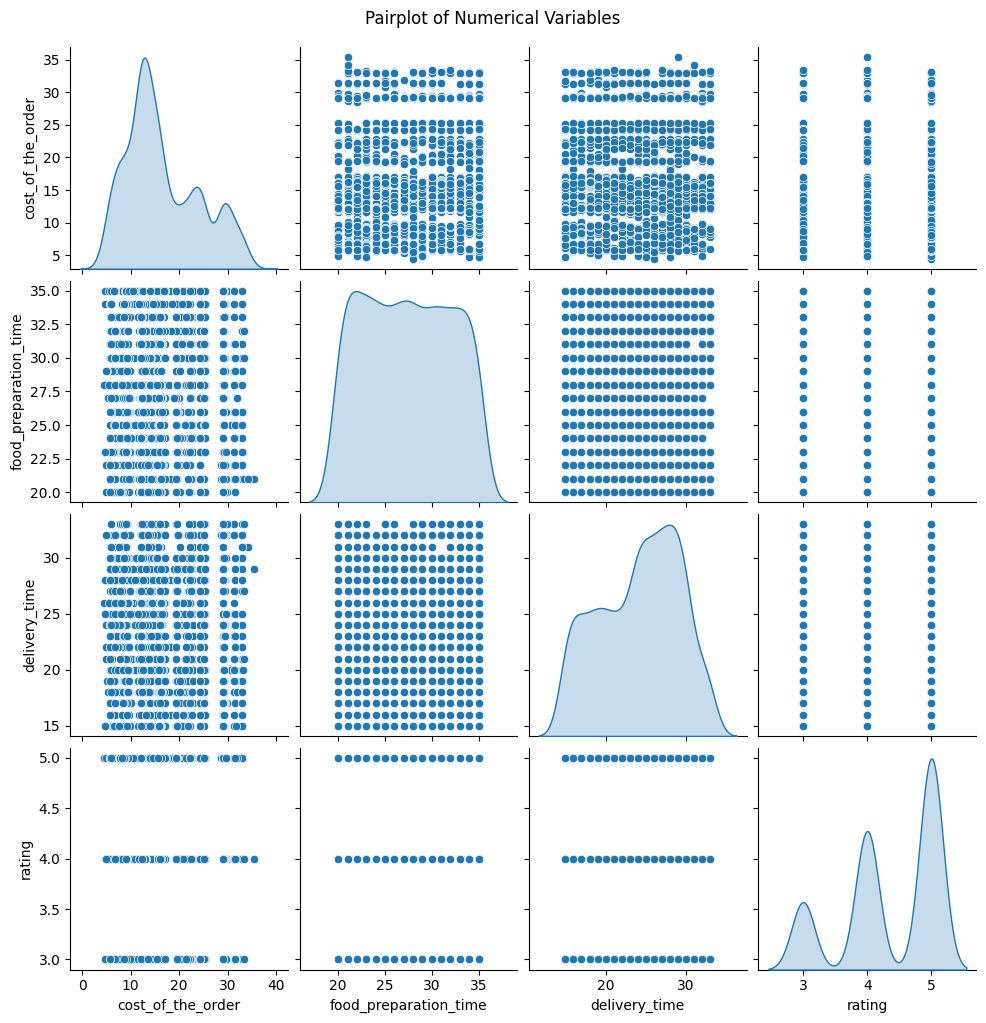

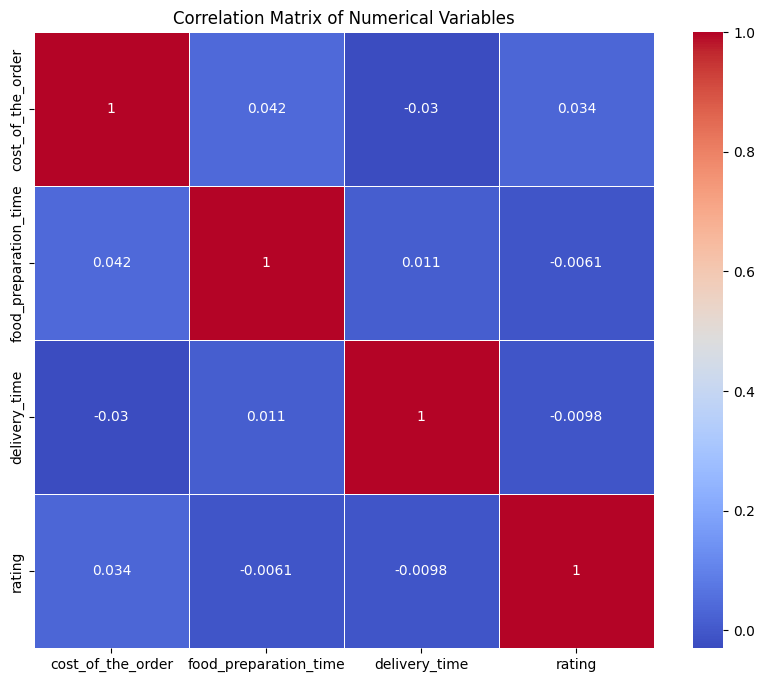

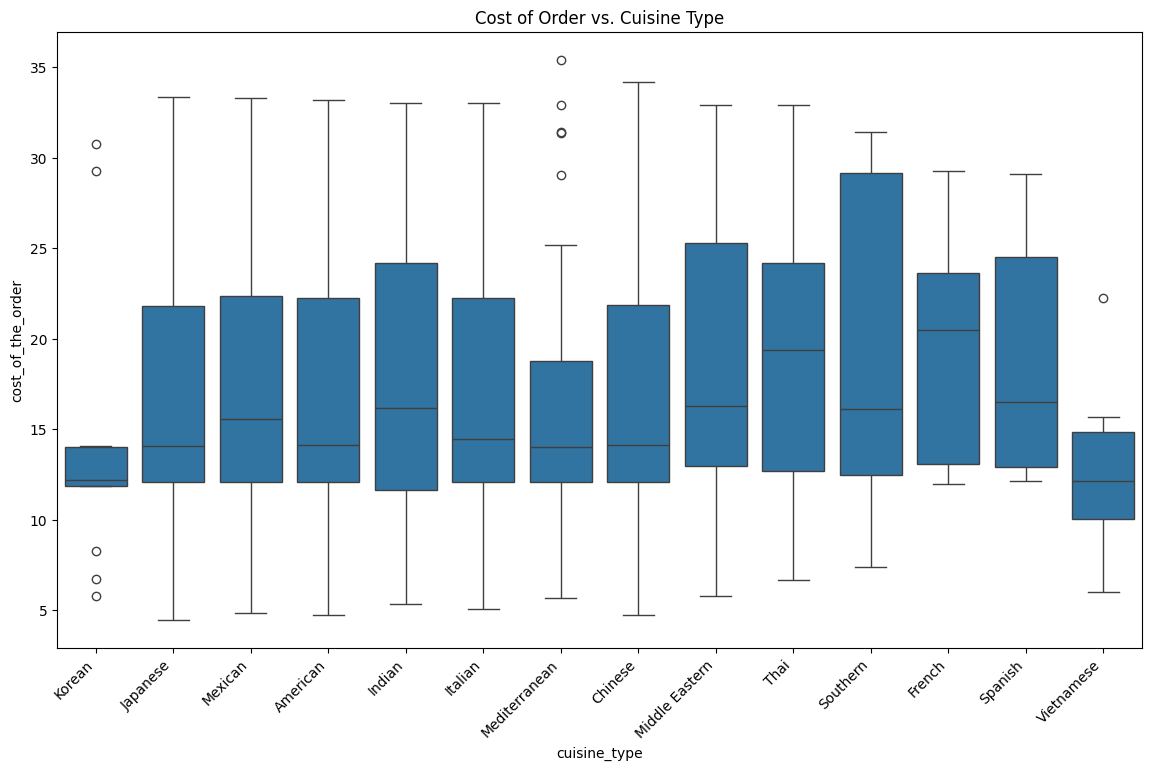

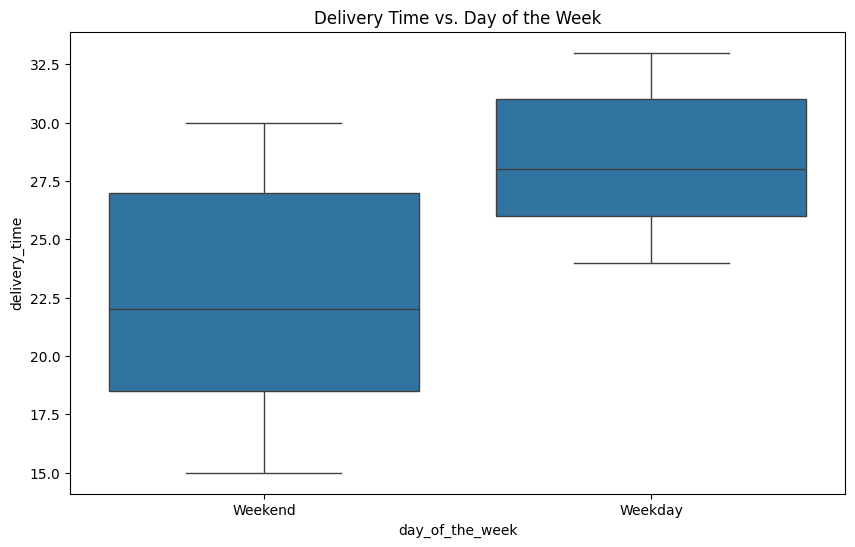

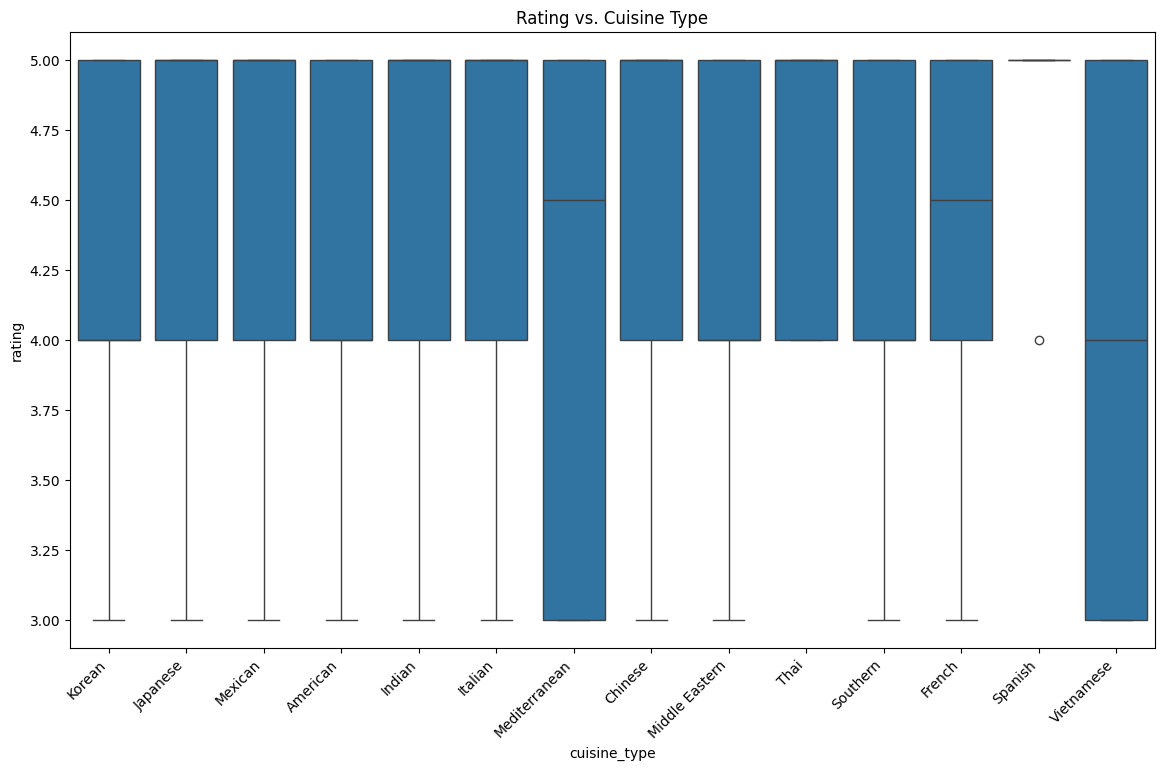

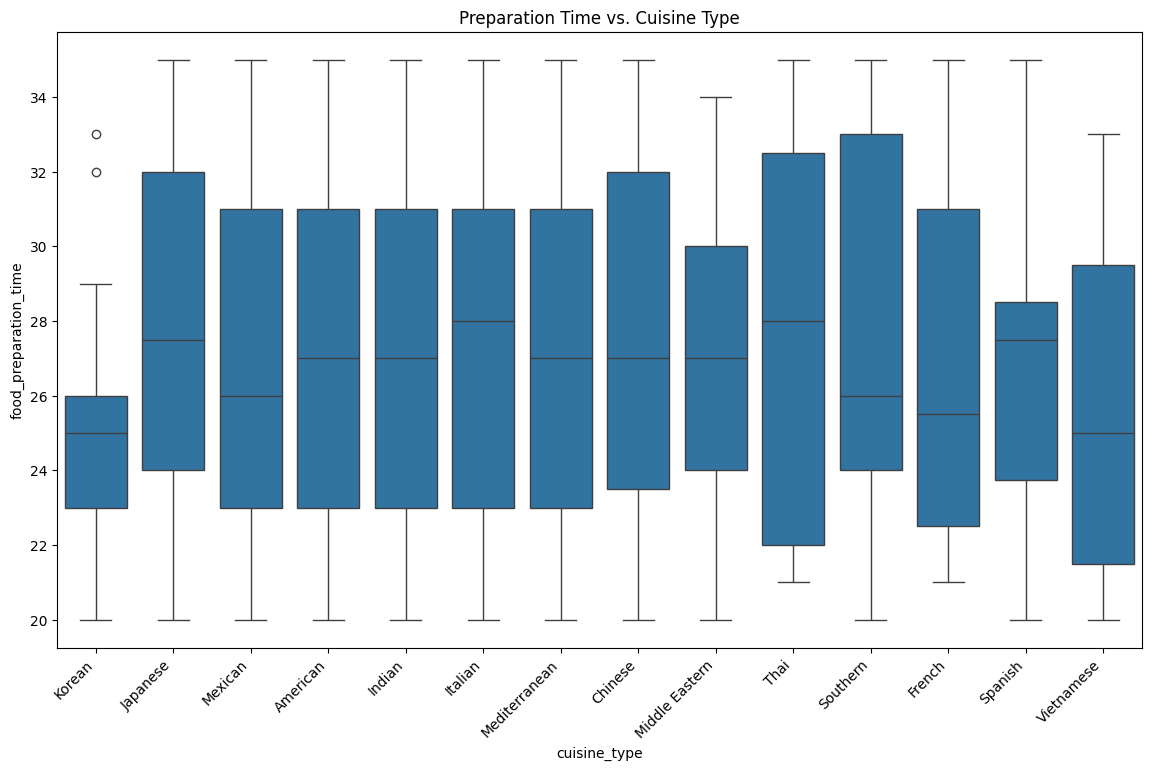

In [21]:
# Write the code here
# Clean the rating column.
df['rating'] = df['rating'].replace('Not given', pd.NA)
df['rating'] = pd.to_numeric(df['rating'])

# Numerical Variables Relationships
numerical_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating']
sns.pairplot(df[numerical_cols], diag_kind='kde')
plt.suptitle("Pairplot of Numerical Variables", y=1.02)
plt.show()

# Correlation Matrix
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=.5)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

# Numerical vs. Categorical Variables
# Cost of Order vs. Cuisine Type
plt.figure(figsize=(14, 8))
sns.boxplot(x='cuisine_type', y='cost_of_the_order', data=df)
plt.title("Cost of Order vs. Cuisine Type")
plt.xticks(rotation=45, ha='right')
plt.show()

# Delivery Time vs. Day of the Week
plt.figure(figsize=(10, 6))
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df)
plt.title("Delivery Time vs. Day of the Week")
plt.show()

# Rating vs. Cuisine Type
plt.figure(figsize=(14, 8))
sns.boxplot(x='cuisine_type', y='rating', data=df)
plt.title("Rating vs. Cuisine Type")
plt.xticks(rotation=45, ha='right')
plt.show()

# Preparation Time vs. Cuisine Type
plt.figure(figsize=(14, 8))
sns.boxplot(x='cuisine_type', y='food_preparation_time', data=df)
plt.title("Preparation Time vs. Cuisine Type")
plt.xticks(rotation=45, ha='right')
plt.show()

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [22]:
# Write the code here
# Clean the rating column.
df['rating'] = df['rating'].replace('Not given', pd.NA)
df['rating'] = pd.to_numeric(df['rating'])

# Group by restaurant and calculate rating count and average rating
restaurant_ratings = df.groupby('restaurant_name').agg(
    rating_count=('rating', 'count'),
    average_rating=('rating', 'mean')
)

# Filter restaurants based on the criteria
eligible_restaurants = restaurant_ratings[
    (restaurant_ratings['rating_count'] > 50) & (restaurant_ratings['average_rating'] > 4)
]

print("Restaurants eligible for the promotional offer:")
print(eligible_restaurants)

Restaurants eligible for the promotional offer:
                           rating_count  average_rating
restaurant_name                                        
Blue Ribbon Fried Chicken            64        4.328125
Blue Ribbon Sushi                    73        4.219178
Shake Shack                         133        4.278195
The Meatball Shop                    84        4.511905


#### Observations:


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [23]:
# Write the code here
#Calculate revenue for orders > $20
revenue_25 = df[df['cost_of_the_order'] > 20]['cost_of_the_order'] * 0.25

# Calculate revenue for orders > $5 and <= $20
revenue_15 = df[(df['cost_of_the_order'] > 5) & (df['cost_of_the_order'] <= 20)]['cost_of_the_order'] * 0.15

# Calculate net revenue
net_revenue = revenue_25.sum() + revenue_15.sum()

print(f"Net revenue generated by the company: ${net_revenue:.2f}")

Net revenue generated by the company: $6166.30


#### Observations:


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [24]:
# Write the code here
# Calculate total time (preparation + delivery)
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

# Count orders with total time > 60 minutes
long_delivery_orders = df[df['total_time'] > 60]
num_long_delivery_orders = len(long_delivery_orders)

# Calculate total number of orders
total_orders = len(df)

# Calculate percentage
percentage_long_delivery = (num_long_delivery_orders / total_orders) * 100

print(f"Percentage of orders taking more than 60 minutes: {percentage_long_delivery:.2f}%")

Percentage of orders taking more than 60 minutes: 10.54%


#### Observations:


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

Mean delivery time on weekdays: 28.34 minutes
Mean delivery time on weekends: 22.47 minutes


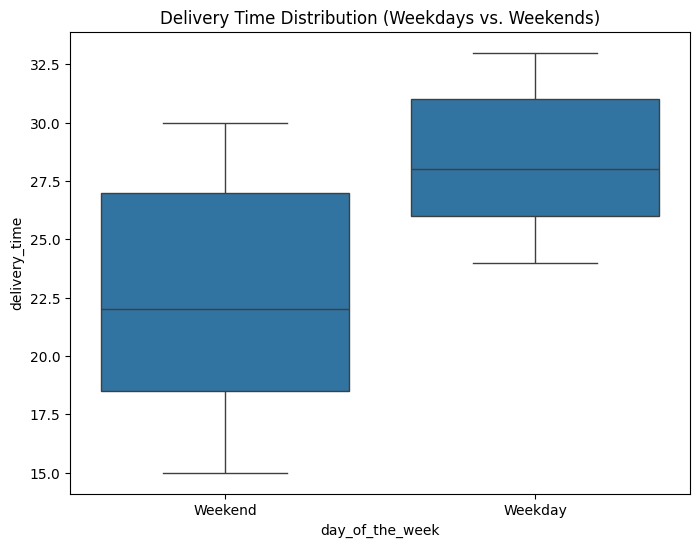

In [25]:
# Write the code here
# Calculate mean delivery time for weekdays and weekends
mean_delivery_weekdays = df[df['day_of_the_week'] == 'Weekday']['delivery_time'].mean()
mean_delivery_weekends = df[df['day_of_the_week'] == 'Weekend']['delivery_time'].mean()

print(f"Mean delivery time on weekdays: {mean_delivery_weekdays:.2f} minutes")
print(f"Mean delivery time on weekends: {mean_delivery_weekends:.2f} minutes")

# Visualize delivery time distribution
plt.figure(figsize=(8, 6))
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df)
plt.title("Delivery Time Distribution (Weekdays vs. Weekends)")
plt.show()


#### Observations:


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
Restaurant Popularity Varies Significantly: Some restaurants receive a much
higher volume of orders than others. This suggests a concentration of demand and potential for partnerships or promotions with popular restaurants.

Cuisine Preferences Exist: Certain cuisine types are more popular than others, particularly on weekends. Understanding these preferences can help FoodHub tailor its offerings and promotions.

Cost Distribution: The cost of orders is right-skewed, indicating that most orders are relatively low-cost, with a tail of higher-cost orders. This suggests potential for targeted promotions based on order value.

Rating Distribution: Ratings are generally high, but there are instances of low ratings. This indicates a need to address issues that lead to poor customer experiences.

Delivery Time Variation: Delivery times vary between weekdays and weekends. Understanding these variations can help optimize delivery logistics.

Total Time: A significant percentage of orders take more than 60 minutes to be delivered, indicating potential inefficiencies in the overall process.

Customer Loyalty: A few customers place a disproportionately large number of orders, highlighting the importance of customer retention.

Promotional Offer Eligibility: Only a few restaurants meet the criteria for the promotional offer, suggesting a need to either adjust the criteria or improve restaurant performance.

Revenue Generation: The company generates revenue based on a tiered commission structure. Understanding the revenue distribution can help in optimizing pricing strategies.

### Recommendations:

Enhance Restaurant Partnerships:
Popular Restaurants: Strengthen partnerships with the top-performing restaurants. Offer them exclusive promotions or featured placements in the app.
Low-Performing Restaurants: Investigate reasons for low order volume. Provide guidance or training to improve their service and attract more customers.

Optimize Cuisine Offerings:
Popular Cuisines: Highlight popular cuisines in the app, especially on weekends. Consider running promotions or discounts on these cuisines.
Expand Cuisine Variety: Explore opportunities to add new and diverse cuisine options to cater to a wider range of customer preferences.

Improve Delivery Efficiency:
Reduce Total Time: Identify bottlenecks in the food preparation and delivery process. Implement strategies to reduce total delivery time (e.g., optimize delivery routes, provide real-time tracking).

Address Weekend Delays: Investigate why delivery times are longer on weekends and implement measures to improve efficiency during these peak periods.

Enhance Customer Experience:
Address Low Ratings: Investigate the reasons for low ratings and take corrective actions. Provide feedback to restaurants and delivery personnel.
Loyalty Program: Implement a loyalty program to reward frequent customers and encourage repeat orders.

Feedback Mechanism: Make it easier for customers to provide feedback and address their concerns promptly.

Optimize Pricing and Promotions:
Targeted Promotions: Offer promotions based on order value, cuisine type, or time of day.

Adjust Commission Structure: Analyze the revenue distribution and consider adjusting the commission structure to maximize profitability.
Data-Driven Decision Making:
Regular Analysis: Continuously analyze data to identify trends, patterns, and areas for improvement.

Restaurant Training and Support:
Rating Improvement: Offer training and support to restaurants to help them improve their food quality, preparation time, and customer service.
Operational Efficiency: Provide guidance on optimizing restaurant operations to reduce preparation time and improve order accuracy.

Real-time Tracking and Communication:
Improve Transparency: Implement real-time tracking for customers and delivery personnel to enhance transparency and communication.
Proactive Communication: Send proactive notifications to customers about order status and delivery updates.

Expand Delivery Network:
Increase Coverage: Expand the delivery network to cover more areas and reach more customers.

Optimize Delivery Personnel: Analyze delivery patterns and optimize the assignment of delivery personnel to reduce delivery times.